In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [45]:
df = pd.read_csv("../data/raw/diabetes_dataset.csv")

df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [46]:
df.shape

(100000, 31)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [48]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [49]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [50]:
print("Class distribution:\n", df['diagnosed_diabetes'].value_counts())

Class distribution:
 diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


In [51]:
print("Class distribution:\n", df['diabetes_stage'].value_counts())

Class distribution:
 diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


In [52]:
print("Class distribution:\n", df['diabetes_risk_score'].value_counts())

Class distribution:
 diabetes_risk_score
26.6    550
27.8    548
26.7    539
27.2    535
28.4    528
       ... 
7.7       1
5.9       1
61.3      1
6.2       1
62.9      1
Name: count, Length: 569, dtype: int64


In [53]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [54]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [56]:
df.select_dtypes(include=['object']).columns

Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'diabetes_stage'],
      dtype='object')

In [57]:
#label encoding for target feature
le = LabelEncoder()
df['diabetes_stage'] = le.fit_transform(df['diabetes_stage'])

# one-hot encode categorical features
df = pd.get_dummies(df, columns=[
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'employment_status',
    'smoking_status'
])

In [58]:
scaler = StandardScaler()

features = df.drop(columns=['diagnosed_diabetes','diabetes_stage','diabetes_risk_score'])

scaled_features = scaler.fit_transform(features)

In [59]:
df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

In [60]:
X_binary = df.drop(columns=['diagnosed_diabetes'])
y_binary = df['diagnosed_diabetes']

In [61]:
X_multi = df.drop(columns=['diabetes_stage'])
y_multi = df['diabetes_stage']

In [62]:
X_reg = df.drop(columns=['diabetes_risk_score'])
y_reg = df['diabetes_risk_score']

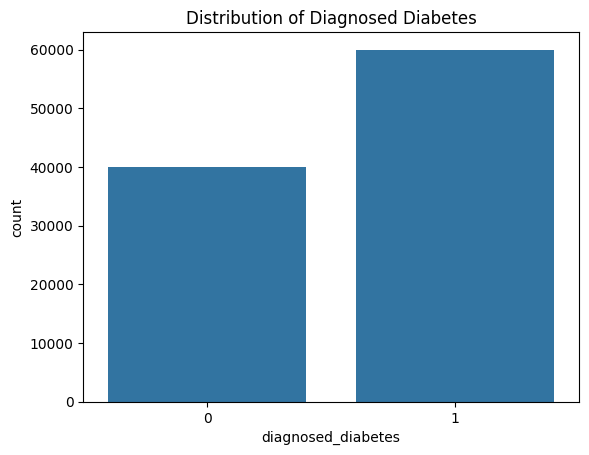

In [63]:
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title("Distribution of Diagnosed Diabetes")
plt.show()

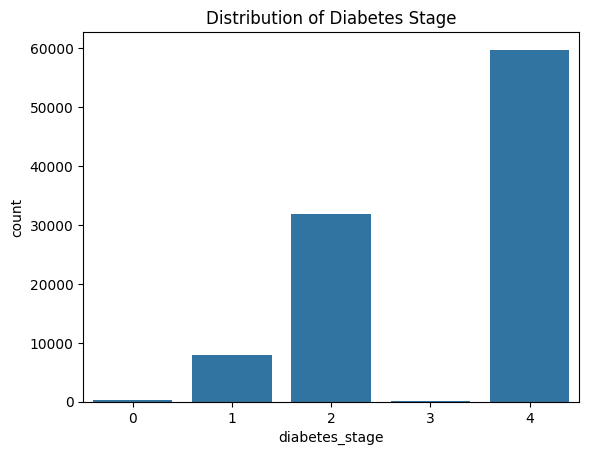

In [64]:
sns.countplot(x='diabetes_stage', data=df)
plt.title("Distribution of Diabetes Stage")
plt.show()

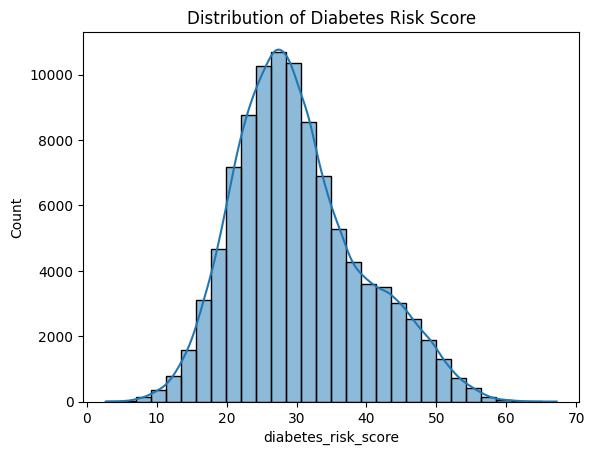

In [65]:
sns.histplot(df['diabetes_risk_score'], bins=30, kde=True)
plt.title("Distribution of Diabetes Risk Score")
plt.show()

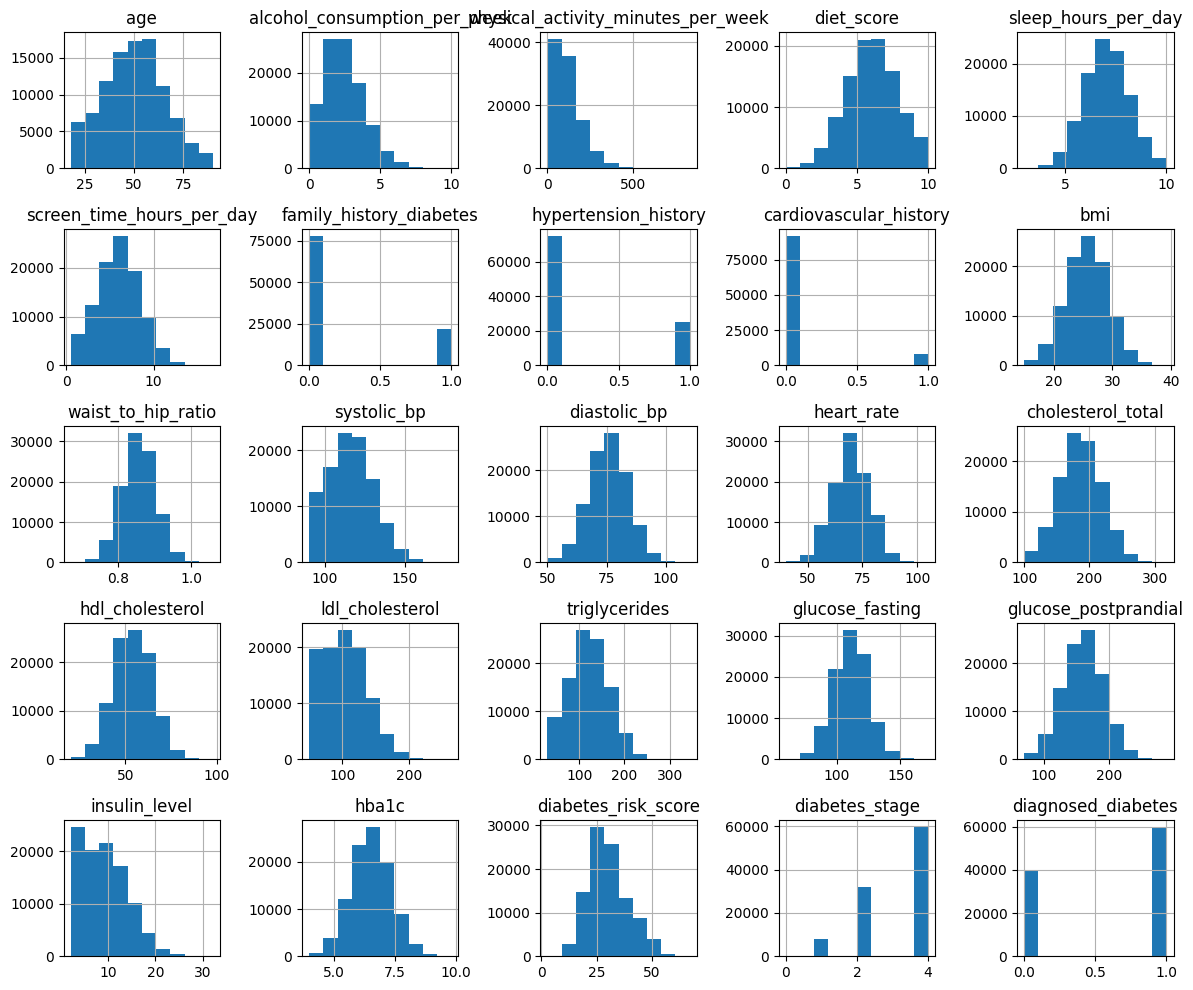

In [66]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

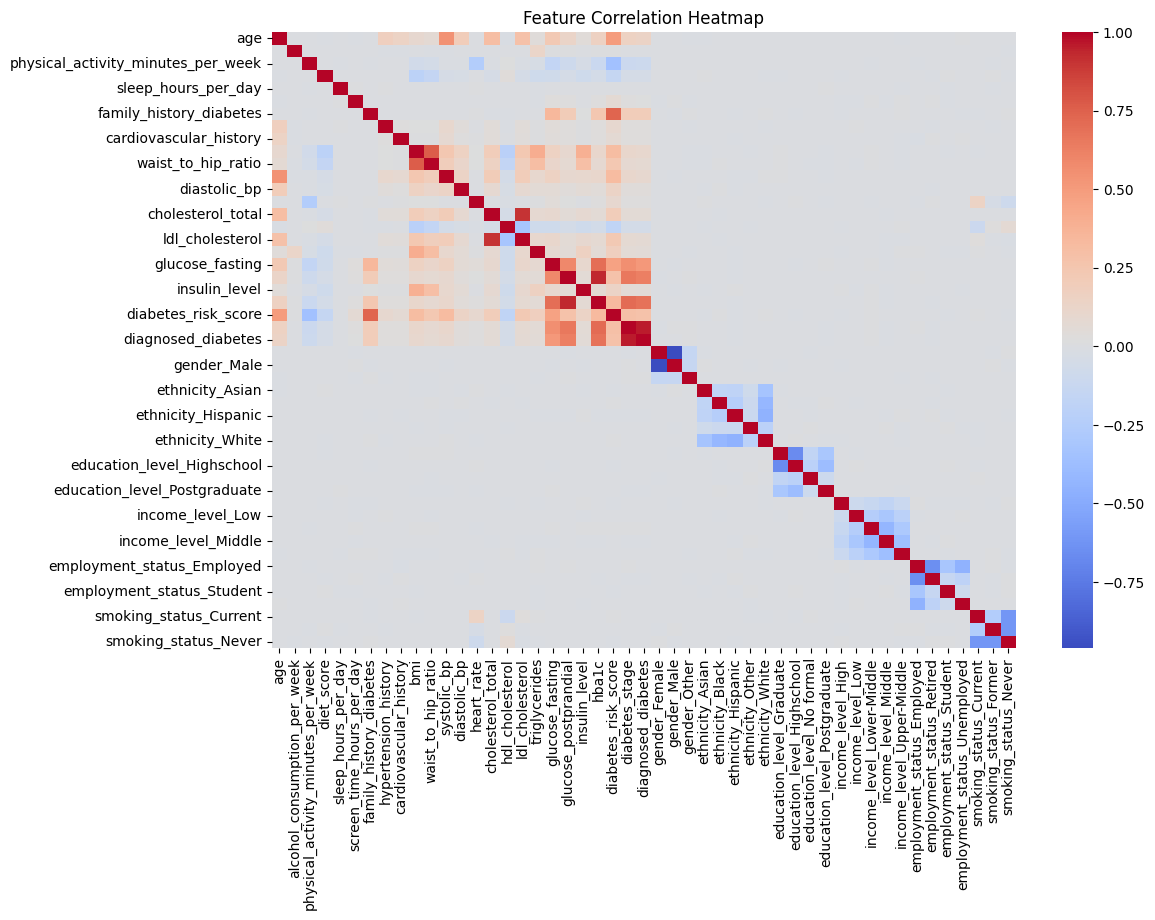

In [72]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

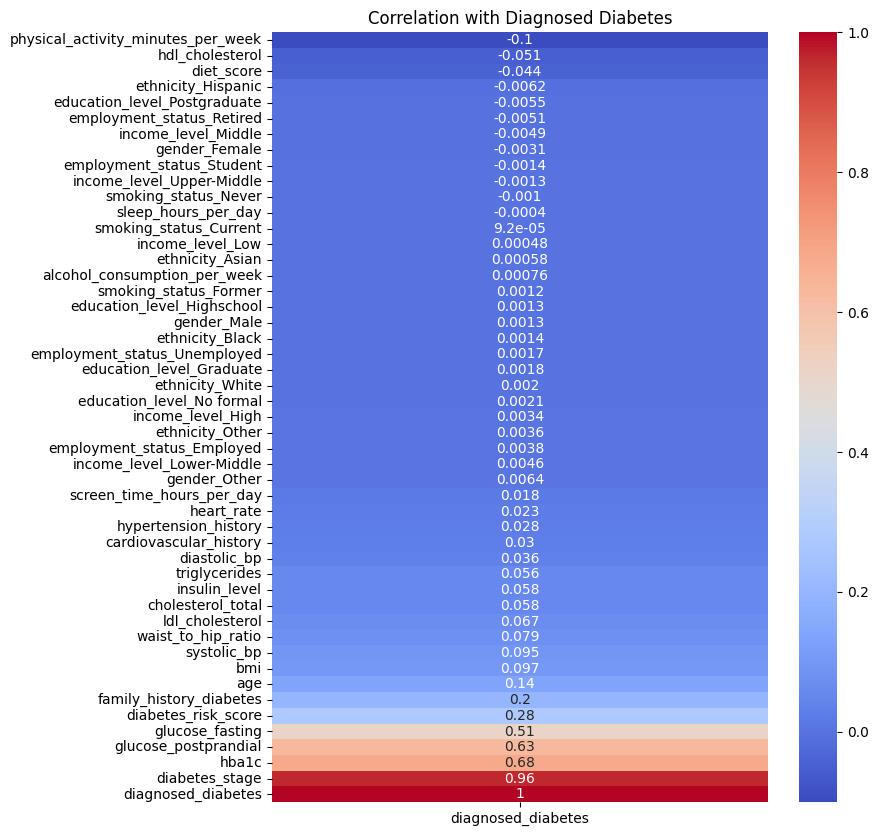

In [74]:
corr_target = df.corr()['diagnosed_diabetes'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diagnosed Diabetes")
plt.show()

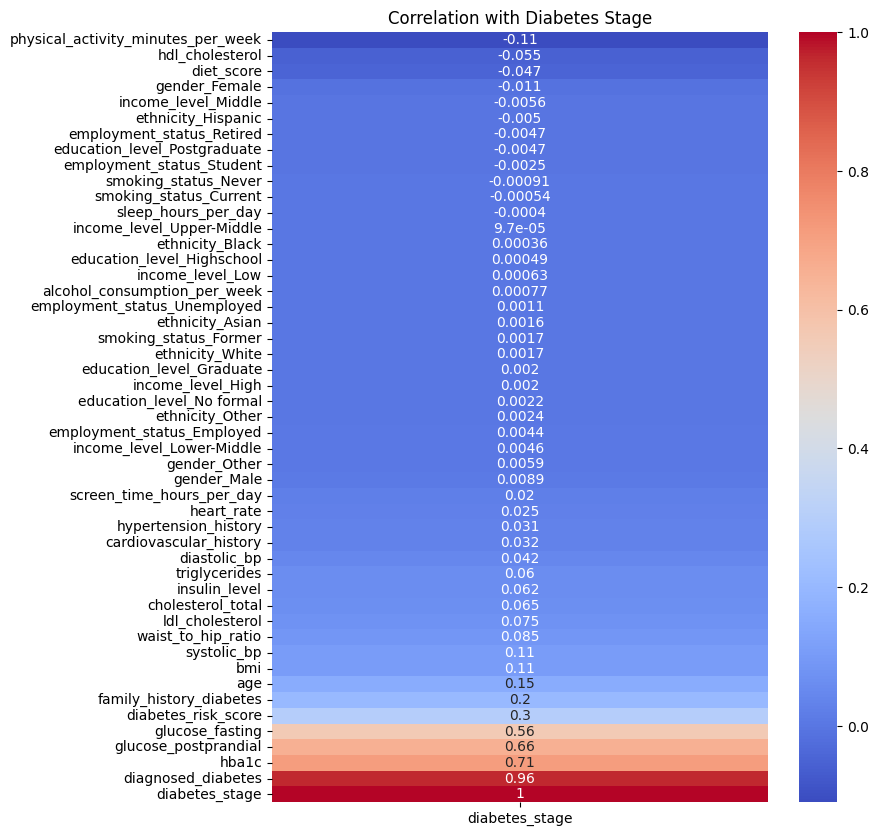

In [75]:
corr_target = df.corr()['diabetes_stage'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diabetes Stage")
plt.show()

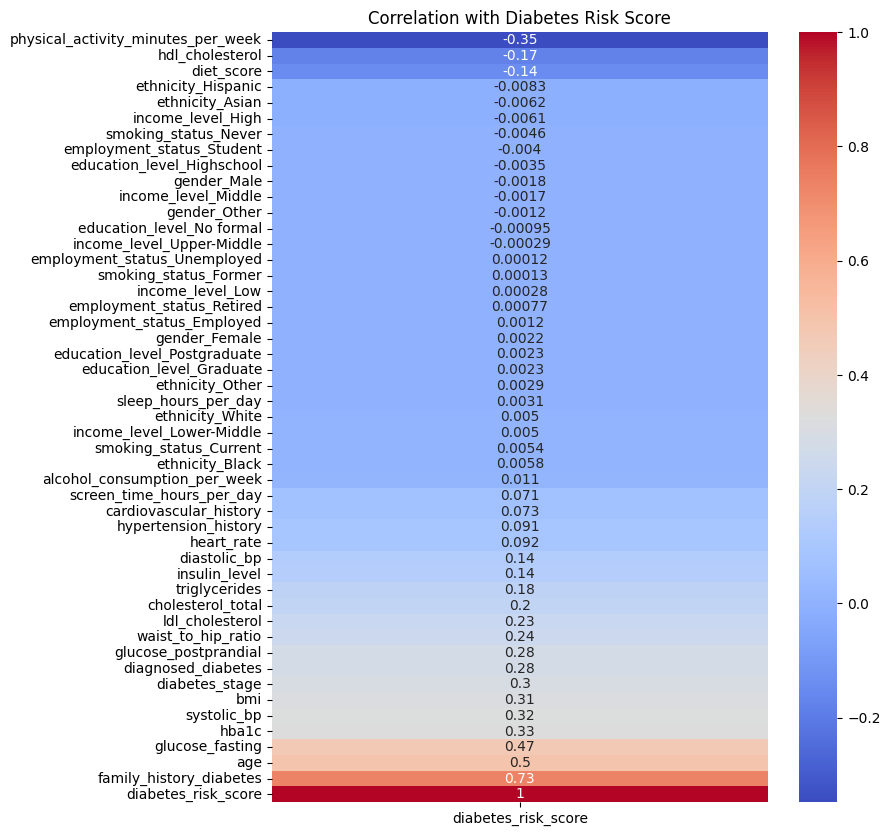

In [76]:
corr_target = df.corr()['diabetes_risk_score'].sort_values()

plt.figure(figsize=(8,10))
sns.heatmap(corr_target.to_frame(), annot=True, cmap="coolwarm")
plt.title("Correlation with Diabetes Risk Score")
plt.show()

In [79]:
top_features = df.corr()['diagnosed_diabetes'].abs().sort_values(ascending=False)[1:6]

top_features

diabetes_stage          0.961453
hba1c                   0.679397
glucose_postprandial    0.629832
glucose_fasting         0.510919
diabetes_risk_score     0.277300
Name: diagnosed_diabetes, dtype: float64

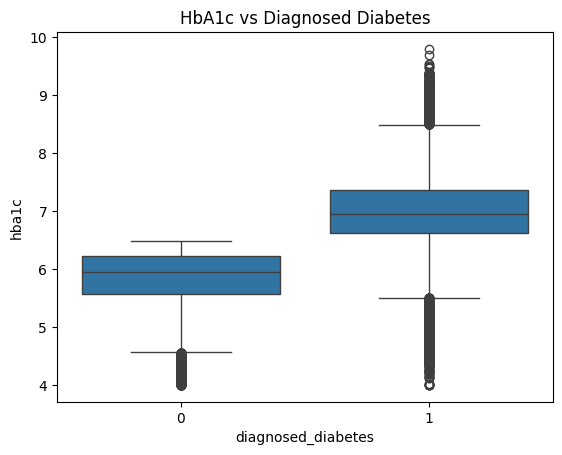

In [ ]:
sns.boxplot(x='diagnosed_diabetes', y='hba1c', data=df)
plt.title("HbA1c vs Diagnosed Diabetes")
plt.show()

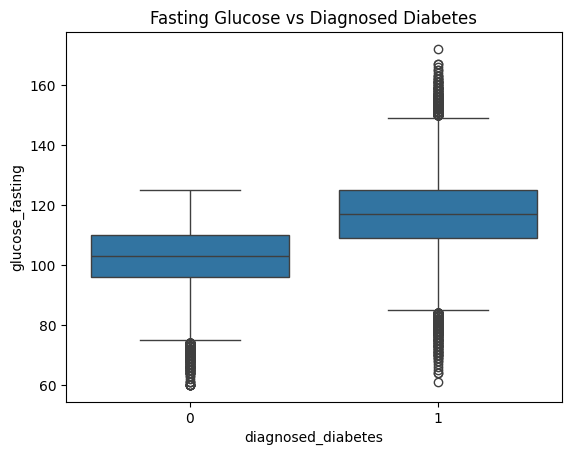

In [81]:
sns.boxplot(x='diagnosed_diabetes', y='glucose_fasting', data=df)
plt.title("Fasting Glucose vs Diagnosed Diabetes")
plt.show()

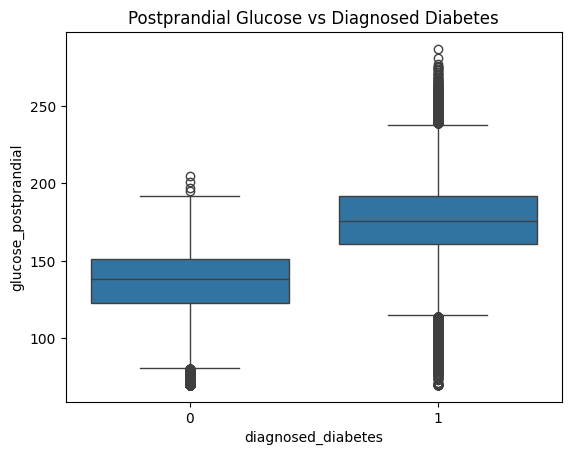

In [82]:
sns.boxplot(x='diagnosed_diabetes', y='glucose_postprandial', data=df)
plt.title("Postprandial Glucose vs Diagnosed Diabetes")
plt.show()

In [83]:
top_features = df.corr()['diabetes_stage'].abs().sort_values(ascending=False)[1:6]

top_features

diagnosed_diabetes      0.961453
hba1c                   0.710258
glucose_postprandial    0.655525
glucose_fasting         0.558491
diabetes_risk_score     0.295138
Name: diabetes_stage, dtype: float64

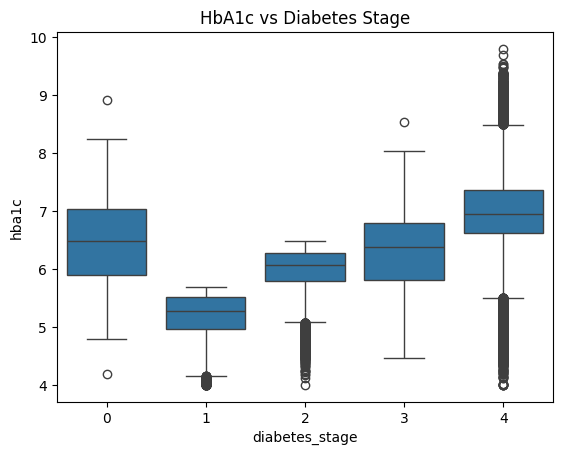

In [84]:
sns.boxplot(x='diabetes_stage', y='hba1c', data=df)
plt.title("HbA1c vs Diabetes Stage")
plt.show()

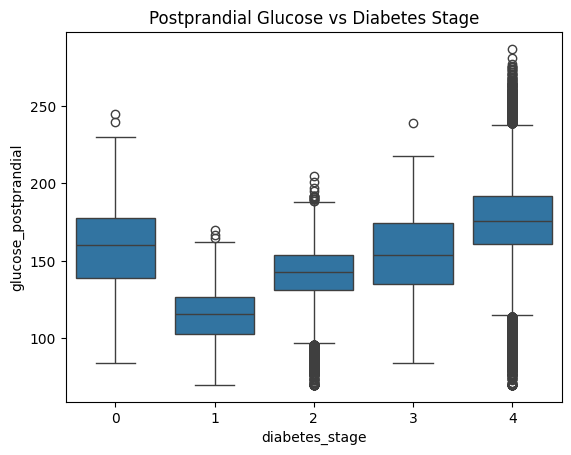

In [85]:
sns.boxplot(x='diabetes_stage', y='glucose_postprandial', data=df)
plt.title("Postprandial Glucose vs Diabetes Stage")
plt.show()

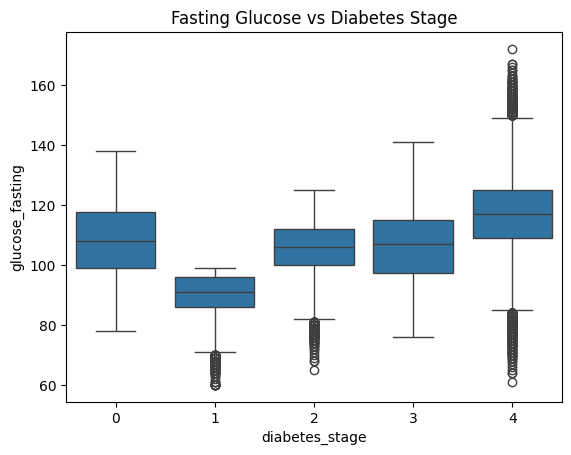

In [86]:
sns.boxplot(x='diabetes_stage', y='glucose_fasting', data=df)
plt.title("Fasting Glucose vs Diabetes Stage")
plt.show()

In [87]:
top_features = df.corr()['diabetes_risk_score'].abs().sort_values(ascending=False)[1:6]

top_features

family_history_diabetes               0.733085
age                                   0.495924
glucose_fasting                       0.469938
physical_activity_minutes_per_week    0.348121
hba1c                                 0.329947
Name: diabetes_risk_score, dtype: float64

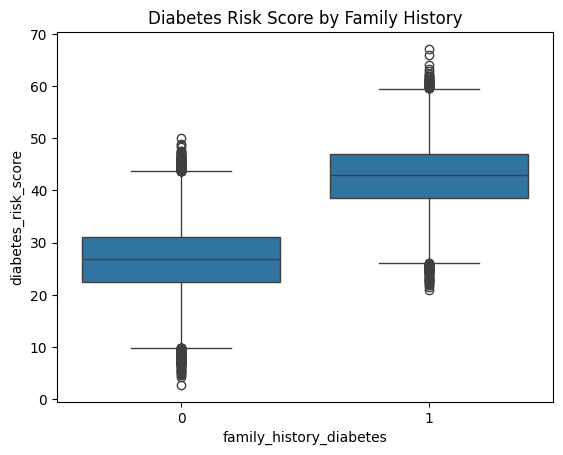

In [88]:
sns.boxplot(x='family_history_diabetes', y='diabetes_risk_score', data=df)
plt.title("Diabetes Risk Score by Family History")
plt.show()

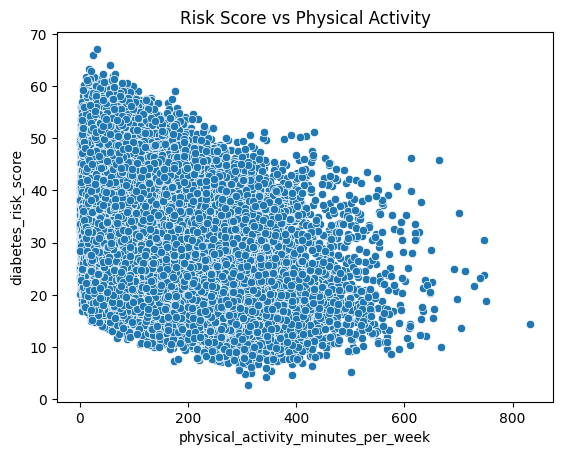

In [97]:
sns.scatterplot(x='physical_activity_minutes_per_week', y='diabetes_risk_score', data=df)
plt.title("Risk Score vs Physical Activity")
plt.show()

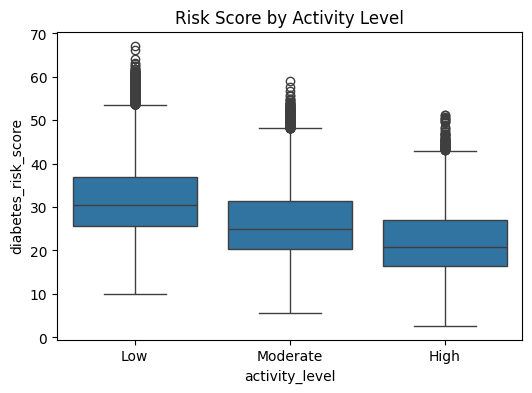

In [98]:
df['activity_level'] = pd.cut(
    df['physical_activity_minutes_per_week'],
    bins=[0,150,300,600],
    labels=['Low','Moderate','High']
)

plt.figure(figsize=(6,4))
sns.boxplot(x='activity_level', y='diabetes_risk_score', data=df)
plt.title("Risk Score by Activity Level")
plt.show()

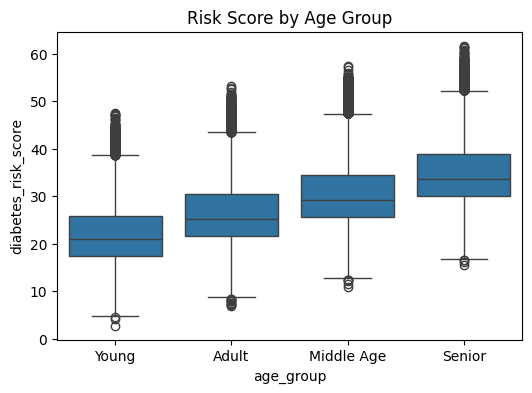

In [91]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0,30,45,60,80],
    labels=['Young','Adult','Middle Age','Senior']
)

plt.figure(figsize=(6,4))
sns.boxplot(x='age_group', y='diabetes_risk_score', data=df)
plt.title("Risk Score by Age Group")
plt.show()

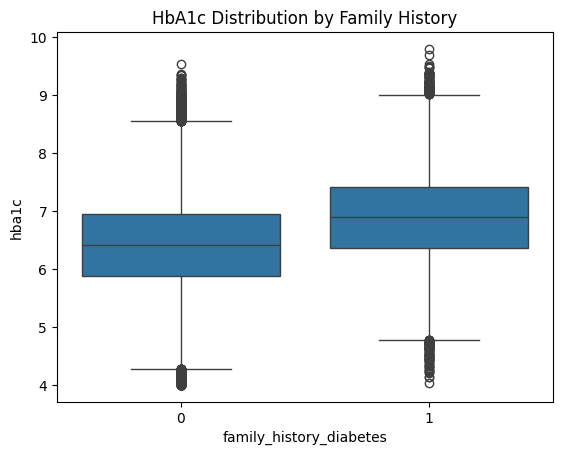

In [92]:
sns.boxplot(x='family_history_diabetes', y='hba1c', data=df)
plt.title("HbA1c Distribution by Family History")
plt.show()

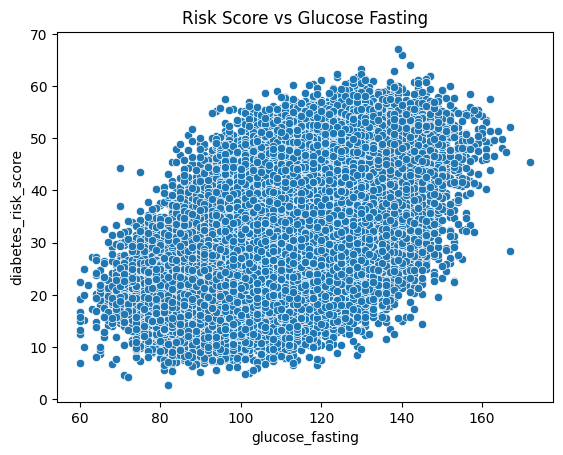

In [100]:
sns.scatterplot(x='glucose_fasting', y='diabetes_risk_score', data=df)
plt.title("Risk Score vs Glucose Fasting")
plt.show()

In [101]:
X_binary = df.drop(columns=['diagnosed_diabetes','diabetes_stage','diabetes_risk_score'])
y_binary = df['diagnosed_diabetes']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_binary, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

In [102]:
X_multi = df.drop(columns=['diabetes_stage','diagnosed_diabetes','diabetes_risk_score'])
y_multi = df['diabetes_stage']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [103]:
X_reg = df.drop(columns=['diabetes_risk_score','diagnosed_diabetes','diabetes_stage'])
y_reg = df['diabetes_risk_score']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)